# Continuous-time linear demo


In [1]:
import jax
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
from cmap.clqt_jax import CLQT 
from linear_model_wv_data import make_wv_data
from cmap.con_to_dis import y
from cmap.linear_estimation_problem import Estimation 
from cmap.convert_est_clqt import est_to_clqt
from cmap.con_to_dis import y_reverse

In [3]:
from cmap.kalman_bucy import kalman_bucy_filter
from cmap.kalman_bucy import continuous_rts_smoother

In [4]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass

In [5]:
steps=10
blocks=5000

In [6]:
steps_all=steps*blocks

In [ ]:
T = 10.0
q = 0.2
v = 0.001
p0 = 0.01

t0=0.0

W = lambda t: q * jnp.eye(2)
H  = lambda t: jnp.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
R  = lambda t: v * jnp.eye(2)
P0 = p0 * jnp.eye(4)

F = lambda t: jnp.array(
        [
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
        ])

L = lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
Q = lambda t: L(t) @ W(t) @ L(t).T

c = lambda t: jnp.zeros((4,))
r = lambda t: jnp.zeros((2,))
x0 = jnp.array([5.0, 5.0, 0.0, 0.0])

dt=T/steps_all

X, y_discrete, _ = make_wv_data(x0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)

est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, x0, T)

ERROR:2025-11-10 15:58:34,841:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/hassan/anaconda3/envs/pcmap/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN


In [8]:
F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)

In [9]:
y_meas=lambda t: y(t,dt,steps_all,y_discrete)
# t_grid = jnp.arange(steps_all) * dt
# s=jnp.stack([y_meas(t) for t in t_grid], axis=0)
# DY_dt_recovered = jnp.stack([y_meas(t) for t in t_grid], axis=0)
# plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
# plt.plot(X[:,0], X[:,1], label='True velocity x')
# plt.show()


In [10]:
T=clqt.T
F=lambda t: -clqt.F(T-t)
H=lambda t: clqt.H(T-t)
R=lambda t: clqt.R(T-t)

W = lambda t: q * jnp.eye(2)
L=lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])



dt=clqt.T/steps_all

t_eval = t0 + dt * jnp.arange(steps_all)

Ps,ms = kalman_bucy_filter(F, L, W, H, R, y_meas, steps_all, dt,t0, P0, x0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, W, t_eval, dt)


In [11]:
 
T=clqt.T
dt = clqt.T / steps / blocks
ST=clqt.ST
vT=clqt.vT

S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT)
phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
x_seq,u_seq =seqForwardPass(clqt, dt, t0, phi0, Kx_seq, d_seq,u_zoh=False)


In [12]:
phis = jnp.linalg.solve(S_seq, v_seq[..., None]).squeeze(-1)


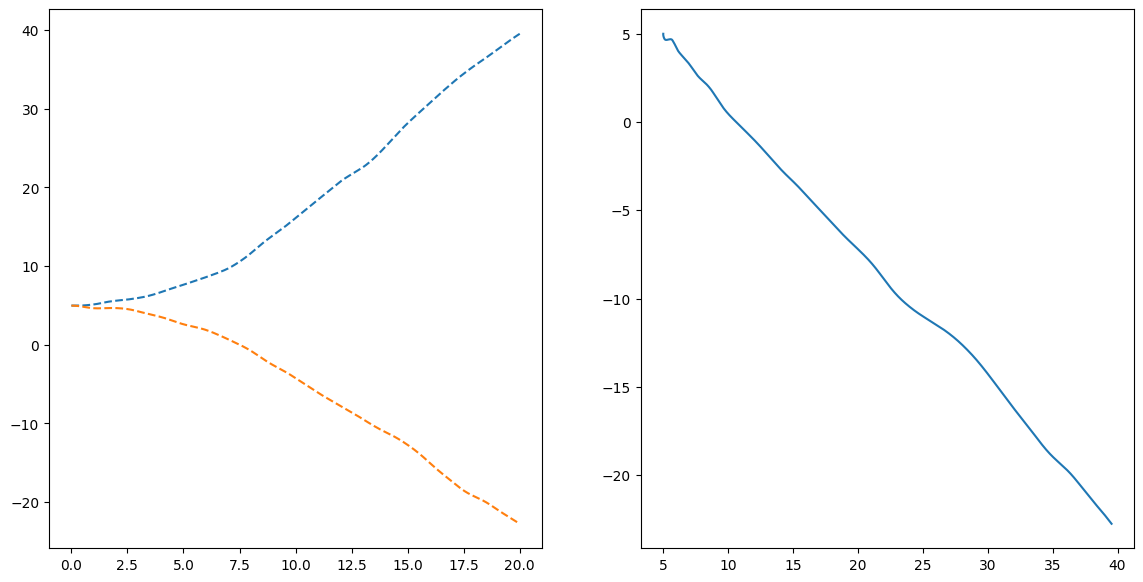

In [13]:
xs3 = jnp.array(x_seq)[::-1]
us3 = jnp.array(u_seq)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])


In [14]:
dt = clqt.T / steps / blocks

Kx_par, d_par, S_par, v_par = parBackwardPass(clqt,blocks,steps,t0,dt)
phi0= jnp.linalg.solve(S_par[0] ,v_par[0])

u_par,x_par = parForwardPass(clqt, phi0, Kx_par, d_par, blocks, steps,dt,t0,u_zoh=False)

In [15]:
phis1 = jnp.linalg.solve(S_par, v_par[..., None]).squeeze(-1)

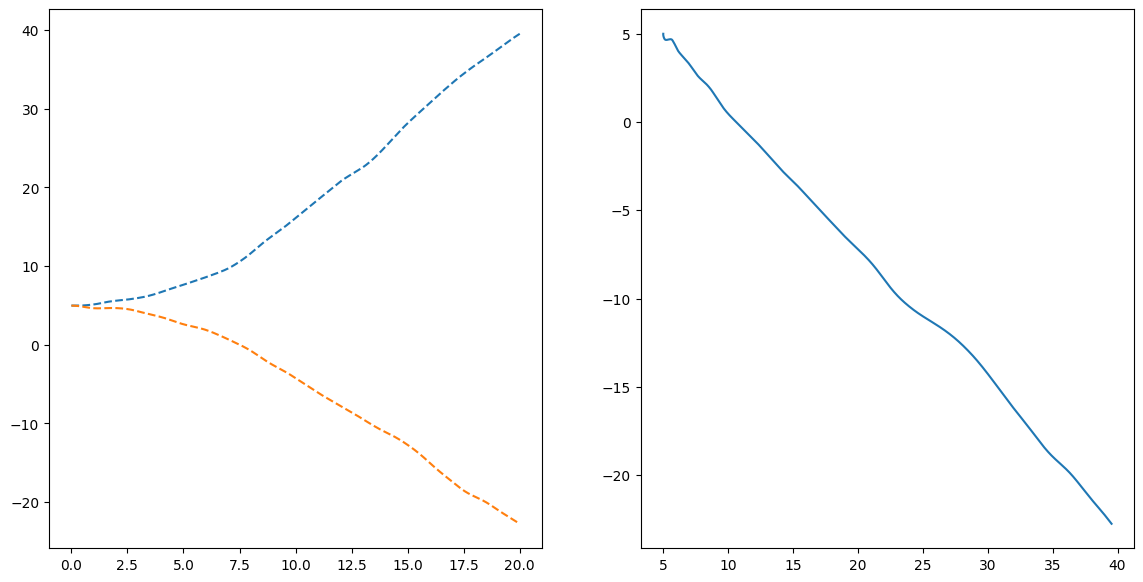

In [16]:
xs4 = jnp.array(x_par)[::-1]

us4 = jnp.array(u_par)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


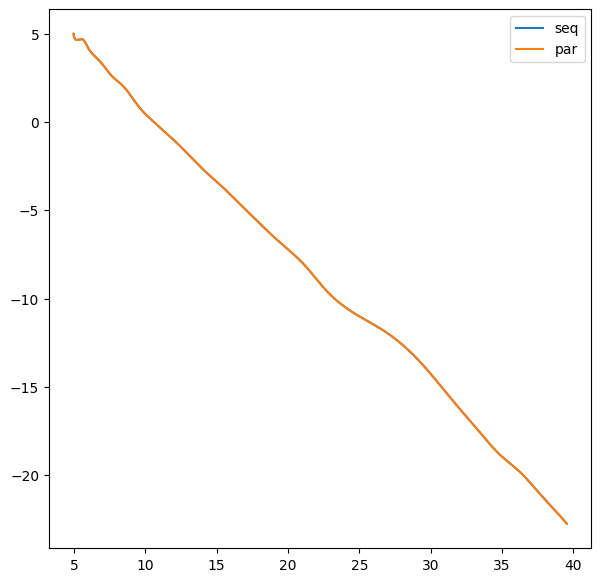

In [17]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1])
ax1.legend( ['seq', 'par'])


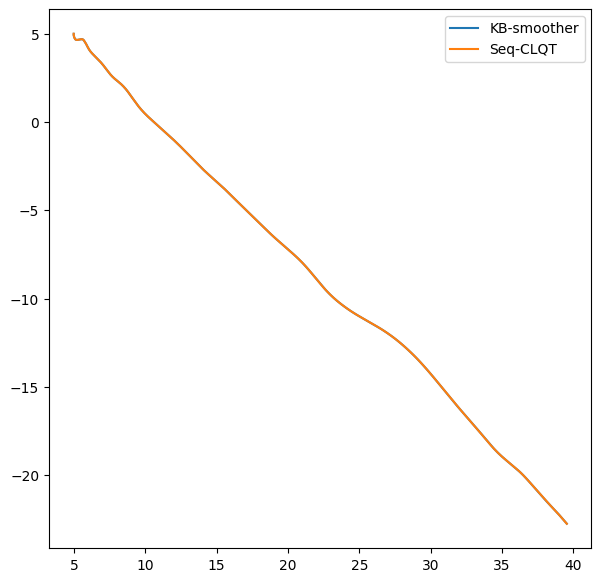

In [18]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms_s[:,0], ms_s[:,1])
ax1.plot(xs3[:,0], xs3[:,1])
ax1.legend( ['KB-smoother', 'Seq-CLQT'])


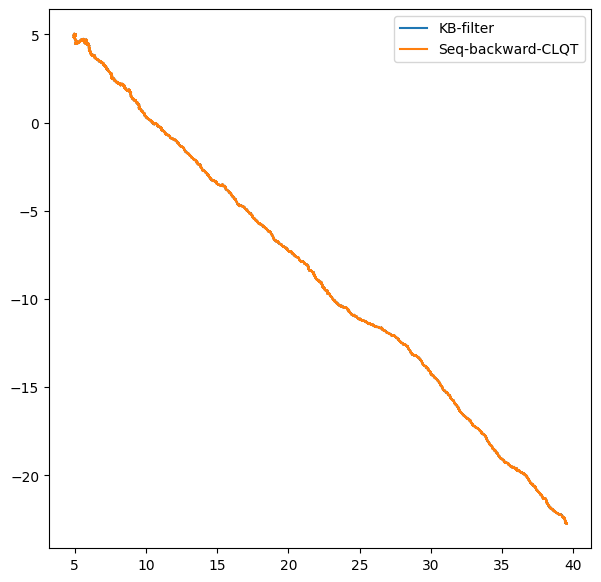

In [19]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms[:,0], ms[:,1])
ax1.plot(phis[:,0], phis[:,1])
ax1.legend( ['KB-filter', 'Seq-backward-CLQT'])


In [20]:
err = jnp.mean(jnp.abs(xs4- xs3))
print(err)

0.0004116744732209491


In [21]:
xs4- xs3

Array([[ 3.53938566e-05, -9.23580427e-05,  2.93241303e-05,
         2.73974976e-04],
       [ 3.54056800e-05, -9.22475759e-05,  2.95585940e-05,
         2.76166932e-04],
       [ 3.54175972e-05, -9.21362323e-05,  2.97929282e-05,
         2.78359048e-04],
       ...,
       [-7.45888303e-04,  6.82777625e-04,  2.87017994e-04,
        -1.24383608e-04],
       [-7.45773495e-04,  6.82727871e-04,  2.87018845e-04,
        -1.24384408e-04],
       [-7.45658687e-04,  6.82678117e-04,  2.87019792e-04,
        -1.24385300e-04]], dtype=float64)

In [22]:
print(jnp.max(jnp.abs(xs3-ms_s)))

0.025945171334720962


In [23]:
print(jnp.mean(jnp.abs(phis[::-1]-ms)))

0.004877671249830133
